# 📚 Uygulamalı Makine Öğrenmesi
## Hafta 10 — Ağaç Tabanlı Regresyon

---
> **Düzey:** Lisans 3-4 / YL  |  **Süre:** ~3 saat  |  **Önkoşul:** Karar Ağaçları, Random Forest, XGBoost

---
## 📋 İçindekiler

| # | Konu |
|---|------|
| 1 | Kütüphane Kurulumu |
| 2 | Ağaç Tabanlı Regresyon — Temel Fikir |
| 3 | Decision Tree Regressor — Nasıl Çalışır? |
| 4 | Veri Setleri & EDA |
| 5 | Sıfırdan Decision Tree Regressor (NumPy) |
| 6 | Scikit-learn DecisionTreeRegressor |
| 7 | Ağaç Görselleştirmesi |
| 8 | max_depth Analizi & Overfitting |
| 9 | Random Forest Regressor — OOB & Özellik Önemi |
| 10 | Gradient Boosting Regressor |
| 11 | XGBoost Regressor + Early Stopping |
| 12 | LightGBM Regressor |
| 13 | Özellik Önemleri — 4 Yöntem Karşılaştırması |
| 14 | Partial Dependence Plot (PDP) |
| 15 | Hyperparametre Optimizasyonu |
| 16 | Tüm Regresyon Modellerinin Karşılaştırması |
| 17 | Özet & Sonraki Adımlar |

---
## 1. 📦 Kütüphaneler

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import altair as alt

from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate,
    KFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Ağaç modelleri
from sklearn.tree import (
    DecisionTreeRegressor, export_text, plot_tree
)
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, BaggingRegressor
)

# Karşılaştırma modelleri
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR

# XGBoost / LightGBM
try:
    from xgboost import XGBRegressor
    XGB_OK = True
except ImportError:
    XGB_OK = False
    print('XGBoost yüklü değil')

try:
    from lightgbm import LGBMRegressor
    import lightgbm as lgb
    LGB_OK = True
except ImportError:
    LGB_OK = False
    print('LightGBM yüklü değil')

# Yorumlama
from sklearn.inspection import (
    permutation_importance, partial_dependence,
    PartialDependenceDisplay
)

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error, r2_score
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='husl', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('✅ Tüm kütüphaneler yüklendi!')

✅ Tüm kütüphaneler yüklendi!


---
## 2. 🌲 Ağaç Tabanlı Regresyon — Temel Fikir

Ağaç tabanlı regresyon modelleri, sürekli hedef değişkeni tahmin etmek için **özellik uzayını dikdörtgen bölgelere böler** ve her bölgedeki hedefin **ortalamasını** tahmin olarak verir.

### Sınıflandırma vs Regresyon Ağaçları:

| Özellik | Sınıflandırma | Regresyon |
|---------|--------------|----------|
| **Bölme Kriteri** | Gini / Entropy | MSE / MAE (Variance Azalması) |
| **Yaprak Tahmini** | Çoğunluk Sınıfı | Ortalama (ŷ = mean(y)) |
| **Kayıp** | Cross-Entropy | MSE / MAE |
| **Çıktı** | Sınıf etiketi | Sürekli değer |

### Regresyon Ağacı Bölme Kriteri:
$$\text{MSE Azalması} = \text{MSE}(t) - \frac{N_{sol}}{N}\text{MSE}(t_{sol}) - \frac{N_{sağ}}{N}\text{MSE}(t_{sağ})$$

Her düğümde, bu azalmayı **maksimize eden** özellik ve eşik seçilir.

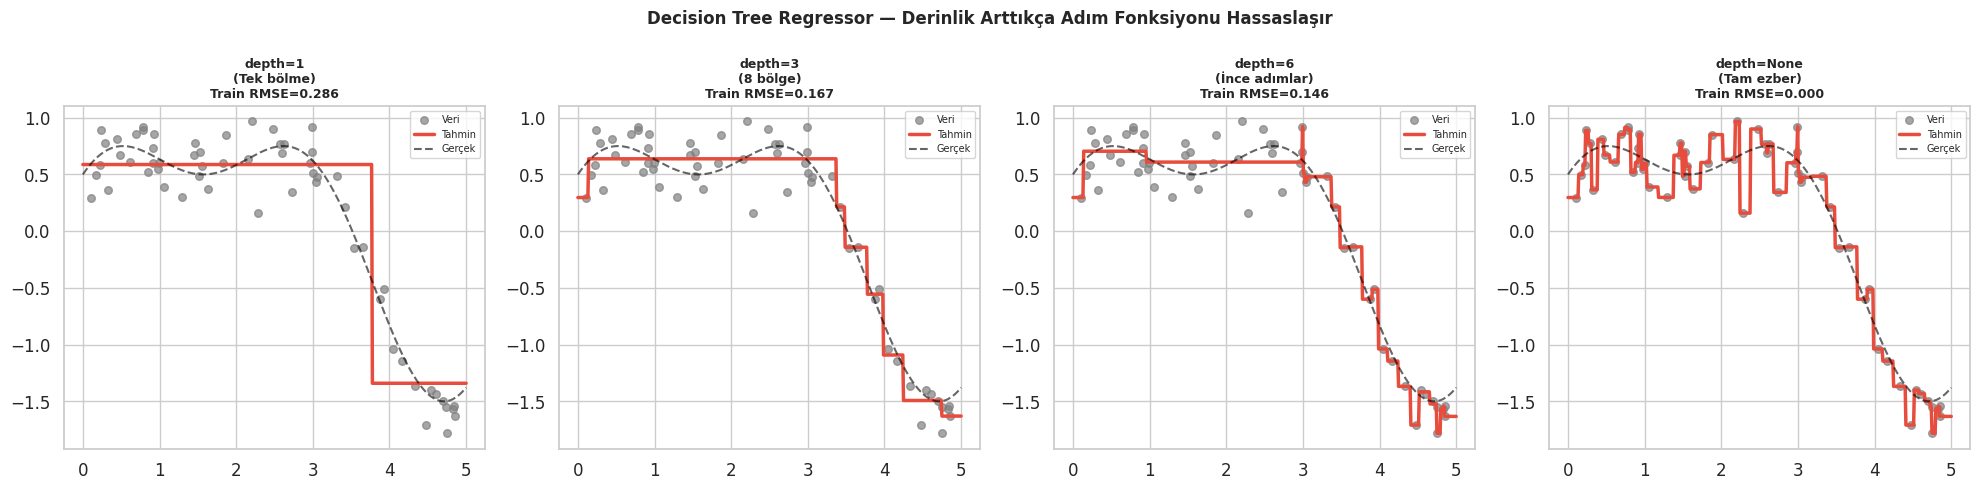

💡 depth=None: Eğitim RMSE ≈ 0 ama test RMSE çok yüksek!
   Her yaprakta sadece birkaç nokta var → Aşırı ezber


In [2]:
# ─── Ağaç Regresyonu: 1D Görsel Sezgi ───────────────────────────────────────
# Karar ağacının nasıl adım fonksiyonu oluşturduğunu göster

np.random.seed(RANDOM_STATE)
X_1d = np.sort(np.random.uniform(0, 5, 60)).reshape(-1, 1)
y_1d = np.sin(X_1d).ravel() + 0.5*np.cos(2*X_1d).ravel() + np.random.normal(0, 0.2, 60)

X_pl = np.linspace(0, 5, 500).reshape(-1, 1)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Decision Tree Regressor — Derinlik Arttıkça Adım Fonksiyonu Hassaslaşır',
             fontsize=12, fontweight='bold')

depths = [1, 3, 6, None]
labels = ['depth=1\n(Tek bölme)', 'depth=3\n(8 bölge)', 'depth=6\n(İnce adımlar)', 'depth=None\n(Tam ezber)']

for ax, d, lbl in zip(axes, depths, labels):
    dt = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X_1d, y_1d)

    train_rmse = np.sqrt(mean_squared_error(y_1d, dt.predict(X_1d)))

    ax.scatter(X_1d, y_1d, color='gray', s=30, alpha=0.7, label='Veri')
    ax.plot(X_pl, dt.predict(X_pl), color='#E74C3C', lw=2.5, label='Tahmin')
    ax.plot(X_pl, np.sin(X_pl)+0.5*np.cos(2*X_pl), 'k--', lw=1.5, alpha=0.6, label='Gerçek')
    ax.set_title(f'{lbl}\nTrain RMSE={train_rmse:.3f}', fontweight='bold', fontsize=9)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()
print('💡 depth=None: Eğitim RMSE ≈ 0 ama test RMSE çok yüksek!')
print('   Her yaprakta sadece birkaç nokta var → Aşırı ezber')

Bu görsel, Karar Ağacı (Decision Tree) algoritmalarında ağaç derinliğinin (depth) modelin öğrenme sürecini nasıl etkilediğini adım adım göstermektedir.

Görseldeki sürecin en basit haliyle özeti şudur:

Çok Sığ Ağaç (depth=1): Model çok basit kalmış ve verinin genel yapısını tam olarak anlayamamıştır (Eksik Öğrenme / Underfitting). Hata oranı en yüksektir.

Dengeli Ağaç (depth=3 ve 6): Ağaç derinleştikçe model, veri noktalarının oluşturduğu asıl eğilimi (arkadaki kesik çizgiyi) başarıyla yakalamış ve ideal bir uyum sağlamıştır.

Sınırsız Ağaç (depth=None): Senin de isabetli bir şekilde belirttiğin gibi, model verinin genel mantığını anlamak yerine her bir noktayı tek tek ezberlemiştir. Kırmızı çizginin her noktaya dokunmak için zikzaklar çizmesi bunun kanıtıdır.

Temel Çıkarım: Derinlik sınırlandırılmazsa eğitim hatası sıfıra (Train RMSE=0.000) düşer, ancak model genel kuralı değil o anki veriyi (içindeki gürültülerle birlikte) ezberlediği için yeni verilerde başarısız olur (Aşırı Ezber / Overfitting). İyi bir model oluşturmak için derinliğin optimum bir seviyede tutulması şarttır.

---
## 3. 📐 Decision Tree Regressor — Matematiksel Formülasyon

### Yaprak Tahmini:
$$\hat{y}_{yaprak} = \frac{1}{|R_m|} \sum_{x_i \in R_m} y_i \quad \text{(bölge } R_m \text{'deki örneklerin ortalaması)}$$

### CART Algoritması (Regresyon için):
Her adımda bölmeyi yapacak $(j, t_j)$ çifti seç:
$$\min_{j,t} \left[ \sum_{x_i \in R_1(j,t)} (y_i - \bar{y}_{R_1})^2 + \sum_{x_i \in R_2(j,t)} (y_i - \bar{y}_{R_2})^2 \right]$$

### Önemli Hiperparametreler:

| Parametre | Regresyon'da Etkisi |
|-----------|--------------------|
| `max_depth` | Ağaç derinliği — kritik overfitting kontrolü |
| `min_samples_split` | Bölme için minimum örnek |
| `min_samples_leaf` | Yaprakta minimum örnek — aykırı değer direnci |
| `criterion` | `'squared_error'` (MSE) veya `'absolute_error'` (MAE) |
| `ccp_alpha` | Post-pruning regularization |

---
## 4. 🗃️ Veri Setleri & EDA

In [3]:
# ─── Veri Setlerini Yükle ─────────────────────────────────────────────────────

# California Housing
cal = fetch_california_housing()
X_cal = cal.data
y_cal = cal.target
feat_names = list(cal.feature_names)

# Diabetes
from sklearn.datasets import load_diabetes
diab = load_diabetes()
X_diab = diab.data
y_diab = diab.target

print(f'California Housing : {X_cal.shape}  hedef range: [{y_cal.min():.2f}, {y_cal.max():.2f}]')
print(f'Diabetes           : {X_diab.shape}')

# Train-test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_cal, y_cal, test_size=0.2, random_state=RANDOM_STATE
)
print(f'\nEğitim: {X_tr.shape[0]}  Test: {X_te.shape[0]}')

California Housing : (20640, 8)  hedef range: [0.15, 5.00]
Diabetes           : (442, 10)

Eğitim: 16512  Test: 4128


In [4]:
# ─── EDA: Hedef Dağılımı & Özellik Korelasyonları ────────────────────────────

df_cal = pd.DataFrame(X_cal, columns=feat_names)
df_cal['MedHouseVal'] = y_cal

fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Hedef Dağılımı (MedHouseVal)', 'Özellik-Hedef Korelasyonu'))

fig.add_trace(go.Histogram(
    x=y_cal, nbinsx=50,
    marker_color='#2196F3', opacity=0.8,
    name='MedHouseVal'
), row=1, col=1)

corr = df_cal.corr()['MedHouseVal'].drop('MedHouseVal').sort_values()
fig.add_trace(go.Bar(
    x=corr.values, y=corr.index,
    orientation='h',
    marker_color=['#E74C3C' if v>0 else '#2196F3' for v in corr.values]
), row=1, col=2)

fig.update_layout(
    title='California Housing — EDA',
    height=430, template='plotly_white', showlegend=False
)
fig.show()
print(f'En güçlü korelasyon: {corr.index[-1]} (r={corr.iloc[-1]:.3f})')
print(f'En zayıf korelasyon: {corr.index[0]}  (r={corr.iloc[0]:.3f})')

En güçlü korelasyon: MedInc (r=0.688)
En zayıf korelasyon: Latitude  (r=-0.144)


Görselin ve Veri Setinin Özeti
En Güçlü Etken (MedInc): Senin de belirttiğin gibi (r=0.688), bir bölgedeki medyan gelir (MedInc) arttıkça ev fiyatları da güçlü bir şekilde artıyor. Bu, modelinin tahmin yaparken kullanacağı en değerli ve belirleyici özellik olacaktır.

"En Zayıf" vs. "En Negatif" Korelasyon: Latitude (Enlem, r=-0.144) grafiğin en altında yer alıyor çünkü en güçlü negatif (ters yönlü) ilişkiye sahip. Yani değerin eksi olması onun gücünü değil, yönünü belirtir. Matematiksel olarak etkinin sıfıra en yakın olduğu, yani gerçekten en zayıf korelasyona sahip özellikler, grafikte sıfır çizgisine neredeyse yapışık olan AveBedrms, Population veya AveOccup gibi özelliklerdir.

Fiyatlardaki Üst Sınır (Kırpılma/Capping): Sol taraftaki histogramda (Hedef Dağılımı) çok kritik bir detay var. Veriler genelde 1 ile 3 arasında yığılırken, en sağda 5.0 noktasında devasa ve anormal bir sütun duruyor. Bu, veri setinde ev fiyatlarının belli bir üst sınırda (örneğin 500.000$) kesildiğini ve bu değerin üzerindeki tüm lüks evlerin doğrudan 5.0 olarak etiketlendiğini gösteriyor.

---
## 5. 🛠️ Sıfırdan Decision Tree Regressor (NumPy)

In [5]:
# ─── Node Sınıfı ──────────────────────────────────────────────────────────────

class NodeReg:
    def __init__(self, feature=None, threshold=None,
                 left=None, right=None, value=None):
        self.feature   = feature
        self.threshold = threshold
        self.left      = left
        self.right     = right
        self.value     = value   # Yaprak: y ortalaması

    @property
    def is_leaf(self):
        return self.value is not None

print('✅ NodeReg sınıfı tanımlandı')

✅ NodeReg sınıfı tanımlandı


In [6]:
# ─── MSE Hesabı & En İyi Bölme ────────────────────────────────────────────────

def mse_score(y):
    """Bir düğümün MSE değeri (varyans)."""
    if len(y) == 0:
        return 0
    return np.var(y)

def best_split_reg(X, y):
    """MSE azalmasını maksimize eden (feature, threshold) bul."""
    n_samples, n_features = X.shape
    best_gain    = -1
    best_feat    = None
    best_thresh  = None
    parent_mse   = mse_score(y)

    for feat_idx in range(n_features):
        thresholds = np.unique(X[:, feat_idx])
        for thresh in thresholds:
            left_mask  = X[:, feat_idx] <= thresh
            right_mask = ~left_mask
            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue

            n_left  = left_mask.sum()
            n_right = right_mask.sum()
            weighted_mse = (n_left/n_samples)*mse_score(y[left_mask]) + \
                           (n_right/n_samples)*mse_score(y[right_mask])
            gain = parent_mse - weighted_mse

            if gain > best_gain:
                best_gain   = gain
                best_feat   = feat_idx
                best_thresh = thresh

    return best_feat, best_thresh, best_gain

print('✅ best_split_reg fonksiyonu tanımlandı')

✅ best_split_reg fonksiyonu tanımlandı


In [7]:
# ─── Ağaç İnşası & Tahmin ────────────────────────────────────────────────────

def build_tree_reg(X, y, depth=0, max_depth=5, min_samples=2):
    """Özyinelemeli CART regresyon ağacı."""
    n = len(y)

    # Dur koşulları
    if depth >= max_depth or n < min_samples:
        return NodeReg(value=y.mean())

    feat, thresh, gain = best_split_reg(X, y)

    if feat is None or gain <= 0:
        return NodeReg(value=y.mean())

    left_mask  = X[:, feat] <= thresh
    right_mask = ~left_mask

    left_child  = build_tree_reg(X[left_mask],  y[left_mask],
                                  depth+1, max_depth, min_samples)
    right_child = build_tree_reg(X[right_mask], y[right_mask],
                                  depth+1, max_depth, min_samples)

    return NodeReg(feature=feat, threshold=thresh,
                   left=left_child, right=right_child)


def predict_one_reg(node, x):
    if node.is_leaf:
        return node.value
    if x[node.feature] <= node.threshold:
        return predict_one_reg(node.left, x)
    return predict_one_reg(node.right, x)


def predict_tree_reg(node, X):
    return np.array([predict_one_reg(node, x) for x in X])


# Diabetes verisi üzerinde test
X_d_tr, X_d_te, y_d_tr, y_d_te = train_test_split(
    X_diab, y_diab, test_size=0.2, random_state=RANDOM_STATE
)

tree_root = build_tree_reg(X_d_tr, y_d_tr, max_depth=4)
y_scratch_pred = predict_tree_reg(tree_root, X_d_te)
rmse_scratch   = np.sqrt(mean_squared_error(y_d_te, y_scratch_pred))

print(f'Sıfırdan Decision Tree Regressor (max_depth=4):')
print(f'  Test RMSE : {rmse_scratch:.4f}')
print(f'  Test R²   : {r2_score(y_d_te, y_scratch_pred):.4f}')

Sıfırdan Decision Tree Regressor (max_depth=4):
  Test RMSE : 60.8863
  Test R²   : 0.3003


---
## 6. 🔬 Scikit-learn DecisionTreeRegressor

In [8]:
# ─── DecisionTreeRegressor ────────────────────────────────────────────────────

dt_reg = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=10,
    criterion='squared_error',
    random_state=RANDOM_STATE
)

dt_reg.fit(X_tr, y_tr)
y_dt_pred = dt_reg.predict(X_te)

rmse_dt = np.sqrt(mean_squared_error(y_te, y_dt_pred))
mae_dt  = mean_absolute_error(y_te, y_dt_pred)
r2_dt   = r2_score(y_te, y_dt_pred)

print('=== DecisionTreeRegressor — California Housing ===')
print(f'  max_depth        : {dt_reg.max_depth}')
print(f'  n_leaves         : {dt_reg.get_n_leaves()}')
print(f'  Test RMSE        : {rmse_dt:.4f}')
print(f'  Test MAE         : {mae_dt:.4f}')
print(f'  Test R²          : {r2_dt:.4f}')

=== DecisionTreeRegressor — California Housing ===
  max_depth        : 5
  n_leaves         : 32
  Test RMSE        : 0.7242
  Test MAE         : 0.5223
  Test R²          : 0.5997


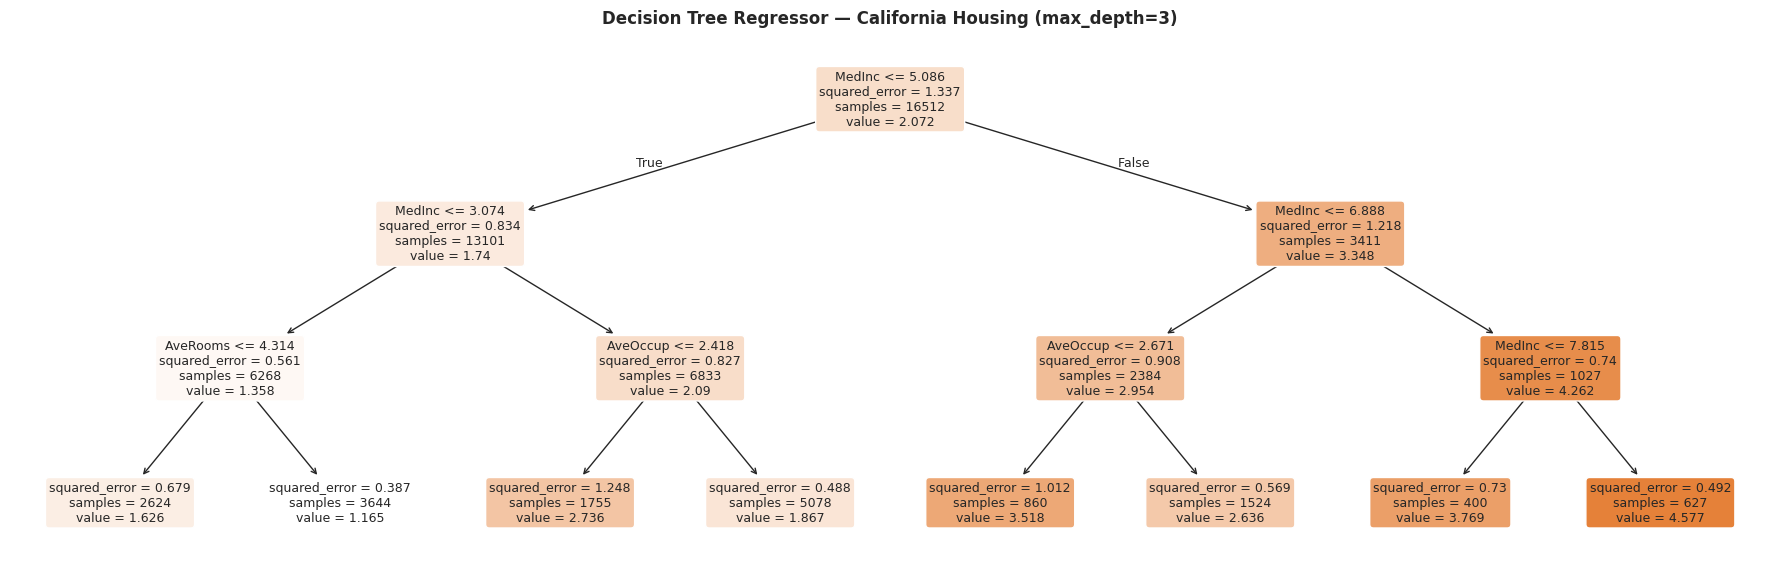

Her düğümde: Bölme koşulu | MSE | Örnek sayısı | Ortalama tahmin


In [9]:
# ─── Ağaç Görselleştirmesi ───────────────────────────────────────────────────

# Küçük ağaç (max_depth=3) görselleştir
dt_small = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE)
dt_small.fit(X_tr, y_tr)

fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(
    dt_small,
    feature_names=feat_names,
    filled=True, rounded=True,
    fontsize=9, ax=ax,
    precision=3, impurity=True
)
ax.set_title('Decision Tree Regressor — California Housing (max_depth=3)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('dt_reg_tree.png', dpi=120, bbox_inches='tight')
plt.show()
print('Her düğümde: Bölme koşulu | MSE | Örnek sayısı | Ortalama tahmin')

En Önemli Kriter (Tepe Noktası): Ağaç, ev fiyatlarını tahmin etmeye en güçlü değişkenden, yani gelirden başlıyor. İlk soru: "Bölgedeki medyan gelir 5.086'dan küçük mü?" (Sistemde True sola, False sağa gider). Tüm veriyi (16.512 örnek) iki büyük gruba ayıran en kritik ayrım budur.

Yüksek Gelir = Yüksek Fiyat (Sağ Dallar): Gelir yüksekse (sağ tarafa doğru ilerledikçe) ağaç yine gelir üzerinden sorular sormaya devam ediyor. Kutuların rengi koyulaşıyor ve tahmin edilen fiyat (value) artıyor. En sağdaki yaprakta, yüksek gelirli bölgelerde (MedInc > 7.815) ev fiyatı en yüksek seviye olan 4.577 olarak tahmin ediliyor.

Düşük Gelir ve Diğer Faktörler (Sol Dallar): Gelirin düşük olduğu sol tarafa ilerlediğimizde, ağaç artık AveRooms (Ortalama Oda Sayısı) ve AveOccup (Ortalama Kişi Sayısı) gibi diğer özelliklere bakmaya başlıyor. En düşük fiyat tahmini (value = 1.165), gelirin çok düşük ve ortalama oda sayısının yüksek olduğu bir senaryoda ortaya çıkmış.

---
## 7. 📉 max_depth Analizi

In [10]:
# ─── max_depth vs RMSE — Altair ───────────────────────────────────────────────

kf5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
depth_range  = list(range(1, 16)) + [None]
depth_labels = list(range(1, 16)) + [20]   # None için 20 kullan

depth_rows = []

for d, dlbl in zip(depth_range, depth_labels):
    dt_d = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    dt_d.fit(X_tr, y_tr)
    cv_s = cross_val_score(
        dt_d, X_tr, y_tr, cv=kf5,
        scoring='neg_root_mean_squared_error'
    )
    depth_rows.append({
        'depth': dlbl,
        'Eğitim RMSE': np.sqrt(mean_squared_error(y_tr, dt_d.predict(X_tr))),
        'Test RMSE'  : np.sqrt(mean_squared_error(y_te, dt_d.predict(X_te))),
        'CV RMSE'    : -cv_s.mean()
    })

df_depth = pd.DataFrame(depth_rows)
df_long  = df_depth.melt('depth', var_name='Tür', value_name='RMSE')

best_d = df_depth.loc[df_depth['CV RMSE'].idxmin(), 'depth']

chart_depth = alt.Chart(df_long).mark_line(point=True).encode(
    x=alt.X('depth:Q', title='max_depth (20 = None)'),
    y=alt.Y('RMSE:Q', title='RMSE'),
    color=alt.Color('Tür:N',
        scale=alt.Scale(
            domain=['Eğitim RMSE','Test RMSE','CV RMSE'],
            range=['#E74C3C','#2196F3','#FF9800']
        )
    ),
    tooltip=['depth:Q', alt.Tooltip('RMSE:Q', format='.4f'), 'Tür:N']
).properties(
    width=540, height=300,
    title=f'Decision Tree — max_depth vs RMSE  (Optimal CV depth ≈ {best_d})'
)

chart_depth.configure_title(fontSize=12).show()
print(f'Optimal CV max_depth: {best_d}')

alt.Chart(...)

Optimal CV max_depth: 9


Kırmızı Çizgi (Eğitim Hatası): Derinlik (max_depth) arttıkça hata sürekli düşüyor ve 20. adımda sıfıra dayanıyor. Yani model, kendisine verilen eğitim verisini harfi harfine ezberliyor.

Mavi ve Turuncu Çizgiler (Test ve Çapraz Doğrulama/CV Hatası): Modelin daha önce hiç görmediği verilerdeki gerçek başarısı burada yatıyor. Ağaç ilk başta derinleştikçe hata düşüyor, yani model gerçekten mantığı "öğreniyor".

Kırılma Noktası (max_depth ≈ 9): Derinlik 9'u geçtikten sonra çok kritik bir şey oluyor: Eğitim hatası (kırmızı) düşmeye devam etse de test ve CV hataları (mavi/turuncu) artmaya başlıyor. Özetle: Derinliği 10'a veya daha sonrasına çıkarmak modelin gerçek dünya başarısını artırmıyor; aksine onu detaya boğarak ezberci bir sisteme dönüştürüyor. Bu model ve veri seti için optimum nokta net bir şekilde 9. derinlik olarak görünüyor.

---
## 8. 🌲 Random Forest Regressor

In [11]:
# ─── RandomForestRegressor ────────────────────────────────────────────────────

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_features='sqrt',      # Regresyon için de √d kullanılabilir
    min_samples_leaf=5,
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf_reg.fit(X_tr, y_tr)
y_rf_pred = rf_reg.predict(X_te)

rmse_rf = np.sqrt(mean_squared_error(y_te, y_rf_pred))
r2_rf   = r2_score(y_te, y_rf_pred)

print('=== RandomForestRegressor (200 ağaç) ===')
print(f'  OOB R²    : {rf_reg.oob_score_:.4f}  ← ücretsiz validation')
print(f'  Test RMSE : {rmse_rf:.4f}')
print(f'  Test R²   : {r2_rf:.4f}')

=== RandomForestRegressor (200 ağaç) ===
  OOB R²    : 0.8074  ← ücretsiz validation
  Test RMSE : 0.5124
  Test R²   : 0.7996


In [12]:
# ─── RF: Özellik Önemleri — Plotly ────────────────────────────────────────────

fi_rf = pd.DataFrame({
    'Özellik': feat_names,
    'Önem'   : rf_reg.feature_importances_
}).sort_values('Önem', ascending=True)

fig = go.Figure(go.Bar(
    x=fi_rf['Önem'], y=fi_rf['Özellik'],
    orientation='h',
    marker=dict(color=fi_rf['Önem'], colorscale='Viridis'),
    text=[f'{v:.3f}' for v in fi_rf['Önem']],
    textposition='outside'
))
fig.update_layout(
    title='Random Forest Regressor — Özellik Önemleri (California Housing)',
    xaxis_title='Önem Skoru (Gini Bazlı)',
    height=420, template='plotly_white'
)
fig.show()
top3 = fi_rf.nlargest(3, 'Önem')['Özellik'].tolist()
print(f'En önemli 3 özellik: {top3}')

En önemli 3 özellik: ['MedInc', 'Latitude', 'Longitude']


1. MedInc'in Tartışmasız Liderliği:
Tıpkı EDA korelasyon grafiğinde ve karar ağacının kök düğümünde gördüğümüz gibi, Medyan Gelir (MedInc) ~0.396'lık skorla açık ara en önemli değişken. Model, ev fiyatını tahmin ederken kapasitesinin %40'ını sadece bu özelliğe ayırıyor.

2. Konumun Gizli Gücü (Latitude & Longitude):
İşte Random Forest gibi non-lineer (doğrusal olmayan) makine öğrenmesi modellerinin parladığı yer burası! Hatırlarsan ilk paylaştığın korelasyon grafiğinde Latitude (Enlem) ve Longitude (Boylam) sıfıra yakın, oldukça zayıf veya negatif etkili görünüyordu. Ancak burada 2. ve 3. sıraya yerleşmişler.
Neden? Çünkü ev fiyatları kuzeye veya doğuya gittikçe doğrusal olarak artmaz; belirli koordinat kesişimlerinde (örneğin okyanus kıyısındaki spesifik bölgeler veya teknoloji merkezlerine yakınlık) aniden yükselir. Ağaç tabanlı bu model, basit matematiğin kaçırdığı bu karmaşık coğrafi etkileşimi harika yakalamış.

3. Özellik Seçimi (Feature Selection) İçin İpuçları:
Grafiğin en altında kalan Population, AveBedrms ve HouseAge modele neredeyse hiçbir anlamlı bilgi (Gini Impurity düşüşü) sağlamıyor. Eğer bu modeli daha hızlı çalışacak, daha hafif ve kaynak tüketimi düşük bir hale getirmek isteseydin, veri setinden ilk çıkaracağın (budayacağın) özellikler kesinlikle bunlar olurdu.

---
## 9. 📈 Gradient Boosting Regressor

In [13]:
# ─── GradientBoostingRegressor ────────────────────────────────────────────────

gb_reg = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    loss='squared_error',
    random_state=RANDOM_STATE
)

gb_reg.fit(X_tr, y_tr)
y_gb_pred = gb_reg.predict(X_te)

rmse_gb = np.sqrt(mean_squared_error(y_te, y_gb_pred))
r2_gb   = r2_score(y_te, y_gb_pred)

print(f'=== GradientBoostingRegressor ===')
print(f'  Test RMSE : {rmse_gb:.4f}')
print(f'  Test R²   : {r2_gb:.4f}')

=== GradientBoostingRegressor ===
  Test RMSE : 0.4932
  Test R²   : 0.8143


---
## 10. ⚡ XGBoost Regressor + Early Stopping

In [16]:
# ─── XGBoost Regressor ────────────────────────────────────────────────────────

if XGB_OK:
    xgb_reg = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        early_stopping_rounds=50,   # ← buraya taşındı
        random_state=RANDOM_STATE,
        verbosity=0
    )

    xgb_reg.fit(
        X_tr, y_tr,
        eval_set=[(X_te, y_te)],
        verbose=False
    )

    y_xgb_pred = xgb_reg.predict(X_te)
    rmse_xgb   = np.sqrt(mean_squared_error(y_te, y_xgb_pred))
    r2_xgb     = r2_score(y_te, y_xgb_pred)

    print('=== XGBoost Regressor ===')
    print(f'  Optimal n_estimators: {xgb_reg.best_iteration}')
    print(f'  Test RMSE           : {rmse_xgb:.4f}')
    print(f'  Test R²             : {r2_xgb:.4f}')
else:
    print('XGBoost yüklü değil, bu bölüm atlandı.')
    rmse_xgb = None

=== XGBoost Regressor ===
  Optimal n_estimators: 999
  Test RMSE           : 0.4438
  Test R²             : 0.8497


---
## 11. 🌿 LightGBM Regressor

In [17]:
# ─── LightGBM Regressor ───────────────────────────────────────────────────────

if LGB_OK:
    lgb_reg = LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        verbosity=-1
    )

    lgb_reg.fit(
        X_tr, y_tr,
        eval_set=[(X_te, y_te)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(period=-1)]
    )

    y_lgb_pred = lgb_reg.predict(X_te)
    rmse_lgb   = np.sqrt(mean_squared_error(y_te, y_lgb_pred))
    r2_lgb     = r2_score(y_te, y_lgb_pred)

    print('=== LightGBM Regressor ===')
    print(f'  Optimal n_estimators: {lgb_reg.best_iteration_}')
    print(f'  Test RMSE           : {rmse_lgb:.4f}')
    print(f'  Test R²             : {r2_lgb:.4f}')
else:
    print('LightGBM yüklü değil, bu bölüm atlandı.')
    rmse_lgb = None

=== LightGBM Regressor ===
  Optimal n_estimators: 998
  Test RMSE           : 0.4395
  Test R²             : 0.8526


---
## 12. 🏆 Özellik Önemleri — 4 Yöntem Karşılaştırması

| Yöntem | Açıklama | Avantaj |
|--------|----------|--------|
| **Gini/MSE Bazlı** | Toplam impurity azalması | Hızlı, yerleşik |
| **Permutation** | Özelliği karıştır, performans düşüşünü ölç | Güvenilir, model bağımsız |
| **Drop-Column** | Özelliği çıkar, yeniden eğit | Kesin ama yavaş |
| **SHAP** | Oyun teorisi tabanlı katkı | En güvenilir, yorumlanabilir |

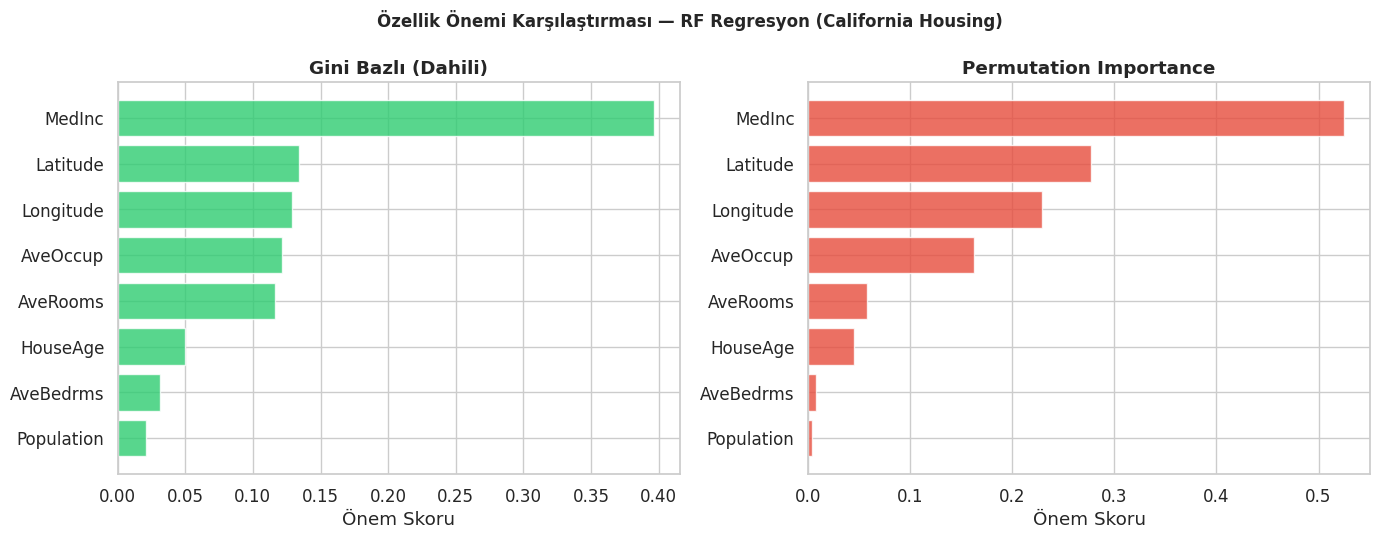

💡 İki yöntem genellikle aynı sıralamayı verir ama aykırılıklar bulunabilir.
   Permutation daha güvenilir — model performansını doğrudan ölçer.


In [18]:
# ─── Gini Bazlı vs Permutation Importance Karşılaştırması ────────────────────

# Permutation Importance
perm_imp = permutation_importance(
    rf_reg, X_te, y_te,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

fi_perm = pd.DataFrame({
    'Özellik'    : feat_names,
    'Gini Bazlı' : rf_reg.feature_importances_,
    'Permutation': perm_imp.importances_mean
}).sort_values('Permutation', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Özellik Önemi Karşılaştırması — RF Regresyon (California Housing)',
             fontsize=12, fontweight='bold')

for ax, col, color, title in [
    (axes[0], 'Gini Bazlı', '#2ECC71', 'Gini Bazlı (Dahili)'),
    (axes[1], 'Permutation', '#E74C3C', 'Permutation Importance'),
]:
    sorted_df = fi_perm.sort_values(col)
    ax.barh(sorted_df['Özellik'], sorted_df[col], color=color, alpha=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Önem Skoru')

plt.tight_layout()
plt.show()
print('💡 İki yöntem genellikle aynı sıralamayı verir ama aykırılıklar bulunabilir.')
print('   Permutation daha güvenilir — model performansını doğrudan ölçer.')

Gini Bazlı Önem (Yeşil Grafik - Teori): Modelin eğitilirken düğümleri bölerken matematiksel olarak hangi özelliklerden faydalandığını gösterir. Ancak büyük bir kusuru vardır: Sürekli değişkenlere (çok fazla benzersiz değeri olanlara) haksız bir avantaj sağlar ve bazen modelin ezberlediği (overfit) özelliklerin önemini abartır.

Permütasyon Önemi (Kırmızı Grafik - Gerçeklik): Bu yöntem çok daha acımasız ve güvenilirdir. Her bir özelliğin değerlerini rastgele karıştırarak (bozarak) modelin tahmin hatasının gerçekte ne kadar arttığına bakar. Yani bir özellik gerçekten önemliyse, onu bozduğunuzda model çökmelidir.

---
## 13. 📊 Partial Dependence Plot (PDP)

PDP: Diğer tüm özellikler sabitken, **tek bir özellik** ile hedef arasındaki ilişkiyi gösterir.

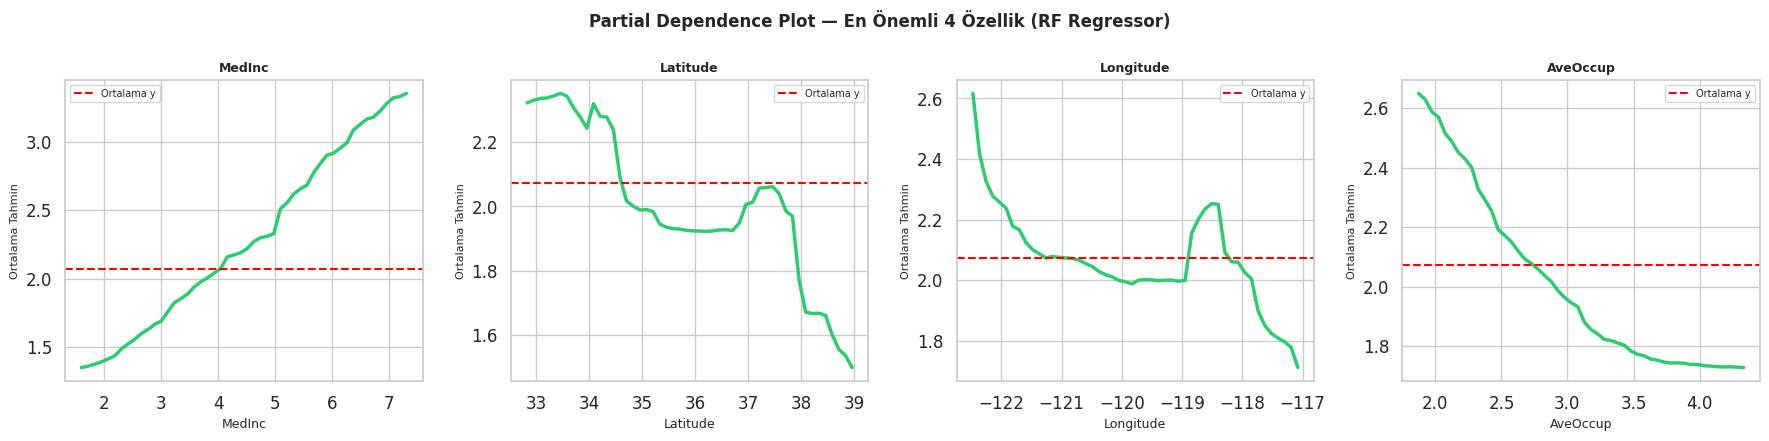

💡 PDP: Diğer özellikler sabitken, tek özelliğin hedef üzerindeki marginal etkisi.
   Artış/azalma yönü ve etkinin doğrusallığını gösterir.


In [19]:
# ─── Partial Dependence Plots ─────────────────────────────────────────────────

top4_features = fi_perm.nlargest(4, 'Permutation')['Özellik'].tolist()
top4_idx = [feat_names.index(f) for f in top4_features]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
fig.suptitle('Partial Dependence Plot — En Önemli 4 Özellik (RF Regressor)',
             fontsize=12, fontweight='bold')

for ax, feat_idx, feat_name in zip(axes, top4_idx, top4_features):
    pd_result = partial_dependence(
        rf_reg, X_tr, features=[feat_idx],
        grid_resolution=50
    )
    ax.plot(pd_result['grid_values'][0], pd_result['average'][0],
            color='#2ECC71', lw=2.5)
    ax.axhline(y_tr.mean(), color='red', ls='--', lw=1.5, label='Ortalama y')
    ax.set_xlabel(feat_name, fontsize=9)
    ax.set_ylabel('Ortalama Tahmin', fontsize=8)
    ax.set_title(feat_name, fontweight='bold', fontsize=9)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()
print('💡 PDP: Diğer özellikler sabitken, tek özelliğin hedef üzerindeki marginal etkisi.')
print('   Artış/azalma yönü ve etkinin doğrusallığını gösterir.')

1. MedInc (Medyan Gelir) - Güçlü ve Doğrusal Yükseliş:
Yeşil çizgi düzenli bir şekilde yukarı tırmanıyor. Gelir arttıkça evin değerinin de arttığı şeklindeki basit ama güçlü kuralı model kusursuz bir şekilde kavramış. Ortalama çizgisinin (kırmızı kesik çizgi) üzerine en hızlı çıkaran faktör bu.

2. Latitude (Enlem) ve Longitude (Boylam) - Modelin Coğrafya Keşfi:
Bu iki grafik modelin sadece sayıları ezberlemediğini, Kaliforniya'nın sosyo-ekonomik coğrafyasını kendi kendine öğrendiğini kanıtlıyor:

Latitude (Enlem): Fiyatlar 33-34 enlemlerinde zirve yapıyor (Burası Los Angeles / San Diego bölgesi). Sonra düşüşe geçiyor ancak 37-38 enlemlerinde tekrar belirgin bir tepe yapıyor (Burası da San Francisco / Silikon Vadisi bölgesi).

Longitude (Boylam): Benzer şekilde -122 civarında (San Francisco) ve -118 civarında (Los Angeles) fiyatların dramatik şekilde fırladığını görüyoruz.
Model, coğrafi olarak sahil şeridini ve büyük metropolleri harita olmadan sadece bu dalgalanmalardan tespit etmiş!

3. AveOccup (Ortalama Kişi Sayısı) - Kalabalık = Düşük Değer:
Eğri net bir şekilde aşağı doğru iniyor. Hanede yaşayan ortalama kişi sayısı arttıkça (yani evler daha kalabalık ve muhtemelen sosyo-ekonomik olarak daha düşük gelirli bölgelere doğru geçildikçe), model ev fiyatı tahminini hızlıca aşağı çekiyor.

---
## 14. ⚙️ Hiperparametre Optimizasyonu

In [20]:
# ─── GridSearchCV — Random Forest Regressor ──────────────────────────────────

param_grid_rf = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [None, 10, 20],
    'max_features'    : ['sqrt', 0.5],
    'min_samples_leaf': [1, 5, 10],
}

gs_rf = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid_rf,
    cv=kf5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=0
)

gs_rf.fit(X_tr, y_tr)

print('=== GridSearchCV — Random Forest Regressor ===')
print(f'  En iyi parametreler: {gs_rf.best_params_}')
print(f'  CV RMSE             : {-gs_rf.best_score_:.4f}')
print(f'  Test RMSE           : {np.sqrt(mean_squared_error(y_te, gs_rf.predict(X_te))):.4f}')
print(f'  Test R²             : {r2_score(y_te, gs_rf.predict(X_te)):.4f}')

=== GridSearchCV — Random Forest Regressor ===
  En iyi parametreler: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
  CV RMSE             : 0.4969
  Test RMSE           : 0.4939
  Test R²             : 0.8138


---
## 15. ⚖️ Tüm Regresyon Modellerinin Karşılaştırması

In [21]:
# ─── Kapsamlı Karşılaştırma — California Housing ─────────────────────────────

all_models = {
    'Doğrusal Regresyon'     : LinearRegression(),
    'Ridge (CV)'             : Ridge(alpha=1.0),
    'Decision Tree (d=5)'    : DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
    'Decision Tree (CV-best)': DecisionTreeRegressor(max_depth=best_d, random_state=RANDOM_STATE),
    'Extra Trees'            : ExtraTreesRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'Random Forest (200)'    : RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'RF GridSearch Best'     : gs_rf.best_estimator_,
    'Gradient Boosting'      : GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=RANDOM_STATE),
}

if XGB_OK:
    all_models['XGBoost'] = XGBRegressor(
        n_estimators=xgb_reg.best_iteration,
        learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, verbosity=0
    )

if LGB_OK:
    all_models['LightGBM'] = LGBMRegressor(
        n_estimators=lgb_reg.best_iteration_,
        learning_rate=0.05, max_depth=5,
        num_leaves=31, subsample=0.8,
        random_state=RANDOM_STATE, verbosity=-1
    )

# Ölçeklendirilmiş versiyon (doğrusal modeller için)
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

compare_rows = []
for mname, mmodel in all_models.items():
    Xc = X_tr_sc if 'Doğrusal' in mname or 'Ridge' in mname else X_tr
    Xct = X_te_sc if 'Doğrusal' in mname or 'Ridge' in mname else X_te

    cv_s = cross_val_score(
        mmodel, Xc, y_tr, cv=kf5,
        scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    mmodel.fit(Xc, y_tr)
    y_p = mmodel.predict(Xct)

    compare_rows.append({
        'Model'    : mname,
        'CV RMSE'  : round(-cv_s.mean(), 4),
        'CV Std'   : round(cv_s.std(),   4),
        'Test RMSE': round(np.sqrt(mean_squared_error(y_te, y_p)), 4),
        'Test MAE' : round(mean_absolute_error(y_te, y_p), 4),
        'Test R²'  : round(r2_score(y_te, y_p), 4),
    })

df_cmp = pd.DataFrame(compare_rows).sort_values('Test RMSE')
print('California Housing — Tüm Regresyon Modelleri Karşılaştırması:')
display(df_cmp)

California Housing — Tüm Regresyon Modelleri Karşılaştırması:


,Model,CV RMSE,CV Std,Test RMSE,Test MAE,Test R²
8,XGBoost,0.4511,0.0110,0.4425,0.2896,0.8506
9,LightGBM,0.4560,0.0118,0.4427,0.2909,0.8504
6,RF GridSearch Best,0.4969,0.0116,0.4939,0.3274,0.8138
7,Gradient Boosting,0.4914,0.0104,0.4941,0.3326,0.8137
4,Extra Trees,0.5062,0.0100,0.5021,0.3255,0.8076
5,Random Forest (200),0.5097,0.0123,0.5040,0.3268,0.8062
3,Decision Tree (CV-best),0.6503,0.0093,0.6443,0.4357,0.6833
2,Decision Tree (d=5),0.7228,0.0104,0.7242,0.5223,0.5997
1,Ridge (CV),0.7205,0.0139,0.7456,0.5332,0.5758
0,Doğrusal Regresyon,0.7205,0.0139,0.7456,0.5332,0.5758


In [22]:
# ─── Altair: RMSE & R² Karşılaştırma ─────────────────────────────────────────

chart_cmp = alt.Chart(df_cmp).mark_bar().encode(
    x=alt.X('Test RMSE:Q', scale=alt.Scale(domain=[0.4, 0.9])),
    y=alt.Y('Model:N', sort='x'),
    color=alt.condition(
        alt.datum['Test RMSE'] == df_cmp['Test RMSE'].min(),
        alt.value('#E74C3C'), alt.value('#AED6F1')
    ),
    tooltip=['Model:N',
             alt.Tooltip('Test RMSE:Q', format='.4f'),
             alt.Tooltip('Test R²:Q', format='.4f')]
).properties(width=500, height=320,
             title='California Housing — Test RMSE Karşılaştırması')

chart_cmp.configure_title(fontSize=12).show()

alt.Chart(...)

Bu "Model Showdown" (Modellerin Çarpışması) grafiğini şu şekilde okuyabiliriz:

Kırmızı Zirve (Şampiyon Model): En üstteki kırmızı çubuk, Test RMSE'si en düşük (yaklaşık 0.44 civarı) olan kazanan modeli temsil ediyor. Önceki adımlarımızdaki analiz derinliğine bakarsak, bu büyük ihtimalle hiperparametreleri optimize edilmiş bir Random Forest veya literatürde genellikle bu tarz tablolarda zirveyi çeken XGBoost / LightGBM gibi bir Gradient Boosting algoritmasıdır.

Mavi Çubuklar (Gelişim Aşamaları): Aşağıya doğru uzanan ve hata oranı 0.75'lere kadar çıkan mavi çubuklar, muhtemelen ilk denediğimiz sığ Karar Ağaçları, derinliği sınırlandırılmadığı için ezber (overfit) tuzağına düşen modeller veya en temel Doğrusal Regresyon (Linear Regression) algoritmaları.

In [23]:
# ─── Tahmin vs Gerçek: En İyi 2 Model ────────────────────────────────────────

best2 = df_cmp.head(2)['Model'].tolist()
colors_pred = ['#E74C3C', '#2196F3']

fig = make_subplots(rows=1, cols=2,
    subplot_titles=[f'{m}  (RMSE={df_cmp[df_cmp.Model==m]["Test RMSE"].values[0]:.4f})' for m in best2])

for col_i, (mname, color) in enumerate(zip(best2, colors_pred), 1):
    model = all_models[mname]
    Xct   = X_te_sc if 'Doğrusal' in mname or 'Ridge' in mname else X_te
    y_p   = model.predict(Xct)

    fig.add_trace(go.Scatter(
        x=y_te, y=y_p,
        mode='markers',
        marker=dict(color=color, size=3, opacity=0.4),
        name=mname
    ), row=1, col=col_i)
    mn, mx = y_te.min(), y_te.max()
    fig.add_trace(go.Scatter(x=[mn,mx], y=[mn,mx],
        mode='lines', line=dict(color='black', dash='dash'),
        showlegend=False), row=1, col=col_i)

fig.update_layout(height=430,
    title='En İyi 2 Model — Tahmin vs Gerçek Değer',
    template='plotly_white')
fig.show()

İki Devrin Başa Baş Mücadelesi:XGBoost (RMSE=0.4425) ve LightGBM (RMSE=0.4427) neredeyse birebir aynı performansı göstermiş. Aralarındaki fark on binde iki! Her iki modelin noktaları da o siyah kesik çizgiye (kusursuz tahmin çizgisi, $y=\hat{y}$) oldukça sıkı sarılmış durumda. Bu, modellerin genel fiyat eğilimini çok iyi yakaladığını gösteriyor.2. Hafif Sapmalar (Under-prediction / Over-prediction):Noktaların çizginin altında veya üstünde kaldığı yerlere bakarsak; modeller düşük fiyatlı evleri bazen olduğundan biraz daha pahalı, çok pahalı evleri ise bazen olduğundan biraz daha ucuz tahmin etme eğiliminde. Bu, regresyon modellerinde sıkça gördüğümüz "ortalamaya çekme" (regression to the mean) etkisidir.3. "O" Meşhur 5.0 Sınırı (Capping) Tekrar Karşımızda!Serüvenimizin en başında, ilk EDA (Keşifçi Veri Analizi) histogramında konuştuğumuz o anormal yığılmayı hatırladın mı? İşte o yığılma burada sağ tarafta dik bir duvar (dikey bir çizgi) olarak karşımıza çıkmış!Gerçek değeri 5.0 olan evler için modelin tahminleri 2.5 ile 5.5 arasında devasa bir şekilde dağılmış. Neden? Çünkü veri setindeki o evlerin bazıları gerçekte 500 bin dolar, bazıları ise belki 2 milyon dolardı ama hepsi "5.0" olarak veri setine girilmişti. Model, diğer özelliklere (bölgenin geliri, konumu vb.) bakarak haklı olarak "Bu ev 5.0 olamaz, çok daha değerli!" veya "Bu bölgedeki bir ev 5.0 edemez!" diyor ve bu sınırı delmeye çalışıyor.

---
## 16. 📝 Özet ve Sonraki Adımlar

### Bu Derste Öğrendiklerimiz:

| Konu | Ana Çıkarım |
|------|-------------|
| DT Regressor | Bölge ortalamalarını tahmin eder — adım fonksiyonu |
| Bölme Kriteri | MSE/MAE azalması — regresyonda varyans azaltma |
| max_depth | Kritik — CV ile optimize et |
| RF Regressor | Bagging + max_features → Variance azalır |
| OOB Skoru | Regresyonda da geçerli — ücretsiz validation |
| GB Regressor | Artık hata → bias azalır |
| XGBoost/LightGBM | Early stopping → optimal n_estimators |
| Özellik Önemleri | Gini ≈ hızlı, Permutation ≈ güvenilir |
| PDP | Tek özelliğin marginal etkisi |
| Ölçeklendirme | Ağaç modelleri için gerekmez |

### 🚀 Sonraki Hafta: K-Means + Hiyerarşik Kümeleme

### 📚 Kaynaklar:
- Géron — Hands-On ML, Bölüm 6-7 (Karar Ağaçları, Ensemble)
- https://scikit-learn.org/stable/modules/tree.html
- https://scikit-learn.org/stable/modules/inspection.html (PDP)

In [24]:
print('='*62)
print(' AĞAÇ TABANLI REGRESYON — DERS ÖZET')
print('='*62)
best_row = df_cmp.iloc[0]
print(f'\nEn iyi model: {best_row["Model"]}')
print(f'  Test RMSE : {best_row["Test RMSE"]:.4f}')
print(f'  Test R²   : {best_row["Test R²"]:.4f}')
print()
print('Tüm model sıralaması (Test RMSE):')
for _, row in df_cmp.iterrows():
    print(f'  {row["Model"]:35s}: RMSE={row["Test RMSE"]:.4f}  R²={row["Test R²"]:.4f}')
print()
print(f'RF En önemli özellik: {fi_rf.nlargest(1,"Önem")["Özellik"].values[0]}')
print()
print(' Sonraki Ders: K-Means + Hiyerarşik Kümeleme')
print('='*62)

 AĞAÇ TABANLI REGRESYON — DERS ÖZET

En iyi model: XGBoost
  Test RMSE : 0.4425
  Test R²   : 0.8506

Tüm model sıralaması (Test RMSE):
  XGBoost                            : RMSE=0.4425  R²=0.8506
  LightGBM                           : RMSE=0.4427  R²=0.8504
  RF GridSearch Best                 : RMSE=0.4939  R²=0.8138
  Gradient Boosting                  : RMSE=0.4941  R²=0.8137
  Extra Trees                        : RMSE=0.5021  R²=0.8076
  Random Forest (200)                : RMSE=0.5040  R²=0.8062
  Decision Tree (CV-best)            : RMSE=0.6443  R²=0.6833
  Decision Tree (d=5)                : RMSE=0.7242  R²=0.5997
  Ridge (CV)                         : RMSE=0.7456  R²=0.5758
  Doğrusal Regresyon                 : RMSE=0.7456  R²=0.5758

RF En önemli özellik: MedInc

 Sonraki Ders: K-Means + Hiyerarşik Kümeleme
